#sumber data dari [https://sumbar.bps.go.id/id](https://)

analisis yang akan dilakukan adalah peramalan jumlah produksi padi di Sumatera Barat menggunakan Analisis Time-Series Prophet untuk 2025-2026

Prophet Forecasting

In [ ]:
#install package
!pip install prophet

In [ ]:
#load library yang diperlukan
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

In [ ]:
# 1. Load data
df = pd.read_excel('Produksi_padi_sumbar.xlsx')

# 2. Mapping bulan (karena pada file excel, kolom data dlm bentuk huruf)
bulan_indo = {
    'januari': 1, 'februari': 2, 'maret': 3, 'april': 4, 'mei': 5, 'juni': 6,
    'juli': 7, 'agustus': 8, 'september': 9, 'oktober': 10, 'november': 11, 'desember': 12
}

# 3. Konversi Bulan ke Angka dan pastikan jadi Integer (Tanpa .0)
df['Bulan_Angka'] = df['Bulan'].str.strip().str.lower().map(bulan_indo)

# Jika ada data kosong, kita hapus dulu agar tidak error saat konversi tanggal
df = df.dropna(subset=['Bulan_Angka'])

# 4. Buat kolom ds dengan format yang lebih aman
# Kita gunakan pd.to_datetime dengan komponen year, month, day secara terpisah
df['ds'] = pd.to_datetime(pd.DataFrame({
    'year': df['Tahun'],
    'month': df['Bulan_Angka'].astype(int),
    'day': 1
}))

df['y'] = df['Produksi']
df_prophet = df[['ds', 'y']].sort_values('ds')

# 5. Inisialisasi Model & Fit
# Meningkatkan fleksibilitas model terhadap perubahan tren
model = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.05)
model.fit(df_prophet)

# 6. Buat Prediksi sampai 2026
future = model.make_future_dataframe(periods=24, freq='MS')
forecast = model.predict(future)

# 7. Hitung Akurasi
actual = df_prophet['y']
predicted = forecast.iloc[:len(df_prophet)]['yhat']
mape = mean_absolute_percentage_error(actual, predicted)
print(f"Akurasi Model (MAPE): {mape:.2%}")

# 8. Simpan Hasil
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_excel('prediksi_padi_final.xlsx', index=False)
print("File berhasil disimpan!")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Akurasi Model (MAPE): 13.92%
File berhasil disimpan!


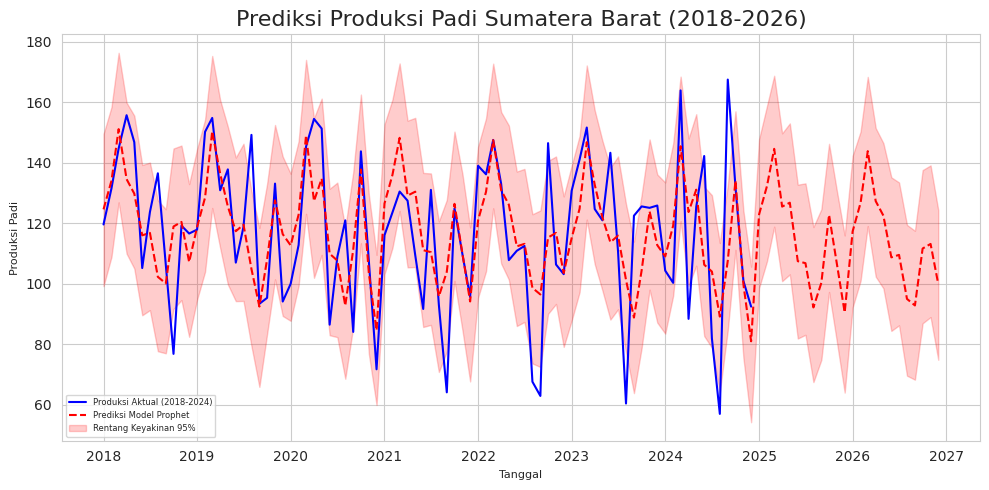

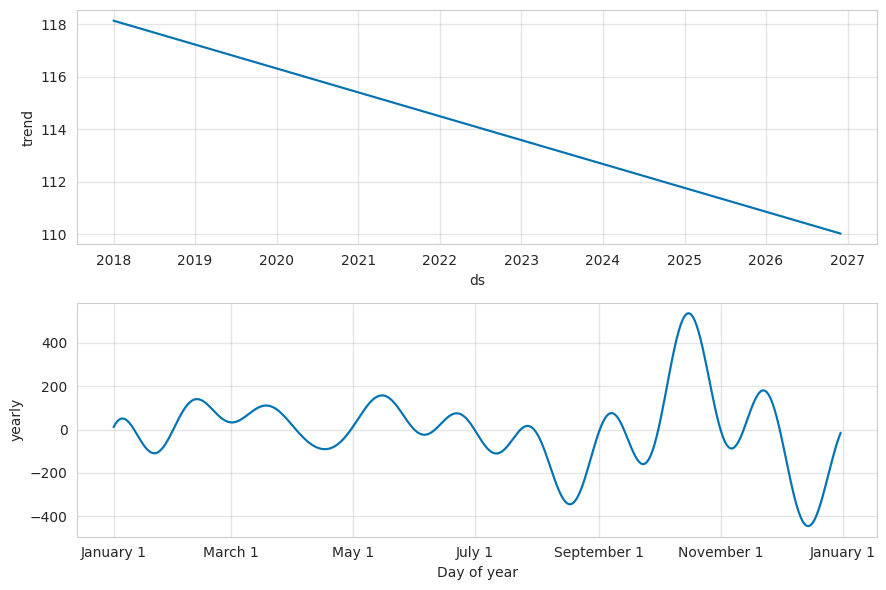

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style plot agar lebih menarik
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))

# Plot data historis
plt.plot(df_prophet['ds'],
         df_prophet['y'],
         label='Produksi Aktual (2018-2024)',
         color='blue'
)

# Plot hasil prediksi (termasuk yang sudah terjadi dan yang akan datang)
plt.plot(forecast['ds'],
         forecast['yhat'],
         label='Prediksi Model Prophet',
         color='red',
         linestyle='--'
)

# Plot rentang keyakinan (uncertainty interval)
plt.fill_between(forecast['ds'],
                 forecast['yhat_lower'],
                 forecast['yhat_upper'],
                 color='red',
                 alpha=0.2,
                 label='Rentang Keyakinan 95%'
)

# Tambahkan Judul dan Label
plt.title('Prediksi Produksi Padi Sumatera Barat (2018-2026)',
          fontsize=16
          )
plt.xlabel('Tanggal', fontsize=8)
plt.ylabel('Produksi Padi', fontsize=8)
plt.legend(fontsize=6)
plt.grid(True)
plt.tight_layout()
plt.show()

# Tambahan: Plot komponen tren dan musiman secara terpisah (dari Prophet)
# Ini akan memberikan insight lebih dalam tentang pola data Anda
fig2 = model.plot_components(forecast)
plt.show()

In [ ]:
# Menghitung total prediksi produksi per tahun
forecast['tahun'] = forecast['ds'].dt.year
ringkasan_tahunan = forecast[forecast['tahun'] >= 2024].groupby('tahun')['yhat'].sum().reset_index()
ringkasan_tahunan.columns = ['Tahun', 'Total_Estimasi_Produksi']

print(ringkasan_tahunan)

   Tahun  Total_Estimasi_Produksi
0   2024              1350.566272
1   2025              1378.509523
2   2026              1368.539880
